In [3]:
import numpy as np
import control as ctrl
import matplotlib.pyplot as plt
import json
import os

import src.utils as utils

### 1)

\begin{align*}
  \dot{v} &= -0.25v - 2r \\
  \dot{r} &= 0.08v - 0.35r + 0.62\tau_r \\
  \dot{\psi} &= r
\end{align*}

Tomando estado $\mathbf{x} = \begin{bmatrix} v & r & \psi \end{bmatrix}^T$, entrada $u_c = \tau_r$ y salida $y = \psi$, queda:

\begin{align*}
  \dot{\mathbf{x}} &= 
  \begin{bmatrix}
    -0.25 & -2 & 0 \\
    0.08 & -0.35 & 0 \\
    0 & 1 & 0
  \end{bmatrix}
  \mathbf{x} +
  \begin{bmatrix} 0 \\ 0.62 \\ 0 \end{bmatrix}
  u_c\\
  y &= \begin{bmatrix} 0 & 0 & 1 \end{bmatrix}
  \mathbf{x}
\end{align*}


### 2)

Para verificar que sea posible diseñar un controlador, se busca que la matriz de controlabilidad $\mathcal{C}$ sea de rango completo. 

En este caso de $3\times3$ se busca:

$$Rg(\mathcal{C}) = Rg(\begin{bmatrix} \mathbf{B} & \mathbf{A}\mathbf{B} & \mathbf{A}^2\mathbf{B} \end{bmatrix}) = 3$$

In [4]:
A = np.array([
    [-0.25, -2, 0],
    [0.08, -0.35, 0],
    [0, 1, 0]
])

B = np.array([
    [0],
    [0.62],
    [0]
])

utils.check_controllability(A, B)

Matriz de controlabilidad:
[[ 0.      -1.24     0.744  ]
 [ 0.62    -0.217   -0.02325]
 [ 0.       0.62    -0.217  ]]

Rango de C: 3
Dimensión del sistema: 3

El sistema es controlable: True


### 3)

Para agregar acción integral y poder rastrear una referencia $\psi_{ref}$, se aumenta el estado con un integrador:

$$\mathbf{x}_a = \begin{bmatrix} v \\ r \\ \psi \\ \xi \end{bmatrix}, \quad \dot{\xi} = \psi_{ref} - \psi$$

El sistema aumentado queda:

\begin{align*}
  \dot{\mathbf{x}}_a &= \mathbf{A}_a\mathbf{x}_a + \mathbf{B}_a\tau_r + \mathbf{E}_a\psi_{ref}
\end{align*}

Donde:

$$\mathbf{A}_a = \begin{bmatrix}
  -0.25 & -2 & 0 & 0 \\
  0.08 & -0.35 & 0 & 0 \\
  0 & 1 & 0 & 0 \\
  0 & 0 & -1 & 0
\end{bmatrix}, \quad
\mathbf{B}_a = \begin{bmatrix} 0 \\ 0.62 \\ 0 \\ 0 \end{bmatrix}, \quad
\mathbf{E}_a = \begin{bmatrix} 0 \\ 0 \\ 0 \\ 1 \end{bmatrix}

### 4)

In [5]:
C = np.array([[0, 0, 1]])

A_a = np.hstack([
    np.vstack([A, -C]), np.zeros((4, 1))
])

B_a = np.vstack([B, np.array([[0]])])

E_a = np.array([[0], [0], [0], [1]])

utils.check_controllability(A_a, B_a)

Matriz de controlabilidad:
[[ 0.        -1.24       0.744     -0.1395   ]
 [ 0.62      -0.217     -0.02325    0.0676575]
 [ 0.         0.62      -0.217     -0.02325  ]
 [ 0.         0.        -0.62       0.217    ]]

Rango de C: 4
Dimensión del sistema: 4

El sistema es controlable: True


### 5)

In [6]:
poles = [-1.5, -2.0, -2.5, -3.0]

Ka = ctrl.place(A_a, B_a, poles)

A_cl = A_a - B_a @ Ka
cl_poles = np.linalg.eigvals(A_cl)
print("\nPolos del sistema en lazo cerrado:")
print(cl_poles)

print("\nValores Ka = [kv, kr, kpsi, ki]:")
print(Ka)


Polos del sistema en lazo cerrado:
[-3.  -2.5 -2.  -1.5]

Valores Ka = [kv, kr, kpsi, ki]:
[[-174.51814516   13.5483871  -304.83870968 -145.16129032]]


### 6)

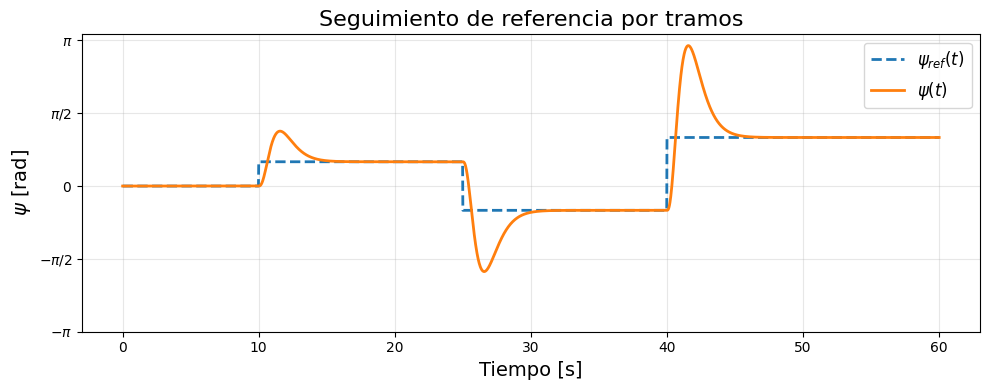

In [7]:
T = np.linspace(0, 60, 3001)
X0 = np.array([0.0, 0.0, 0.0, 0.0])

psi_ref = np.zeros_like(T)
psi_ref[(T >= 10) & (T < 25)] = np.pi/6
psi_ref[(T >= 25) & (T < 40)] = -np.pi/6
psi_ref[(T >= 40) & (T <= 60)] = np.pi/3

A_cl = A_a - B_a @ Ka
sys_cl = ctrl.ss(A_cl, E_a, np.eye(4), np.zeros((4, 1)))
    
T_sim, y_out = ctrl.forced_response(sys_cl, T, psi_ref, X0)

label_fontsize = 14
legend_fontsize = 12
title_fontsize = 16

plt.figure(figsize=(10, 4))
plt.plot(T_sim, psi_ref, '--', label=r'$\psi_{ref}(t)$', linewidth=2)
plt.plot(T_sim, y_out[2, :], label=r'$\psi(t)$', linewidth=2)
plt.xlabel('Tiempo [s]', fontsize=label_fontsize)
plt.ylabel(r'$\psi$ [rad]', fontsize=label_fontsize)
plt.title('Seguimiento de referencia por tramos', fontsize=title_fontsize)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=legend_fontsize)
plt.yticks(
    [-np.pi, -np.pi/2, 0, np.pi/2, np.pi],
    [r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$']
)
plt.tight_layout()
plt.show()


### 7)

In [8]:
# Estados simulados
v = y_out[0, :]
r = y_out[1, :]
psi = y_out[2, :]
xi = y_out[3, :]

# Error de seguimiento
e = psi_ref - psi

# Señal de control: tau_r = -Ka * xa
tau_r = -(Ka @ y_out).flatten()

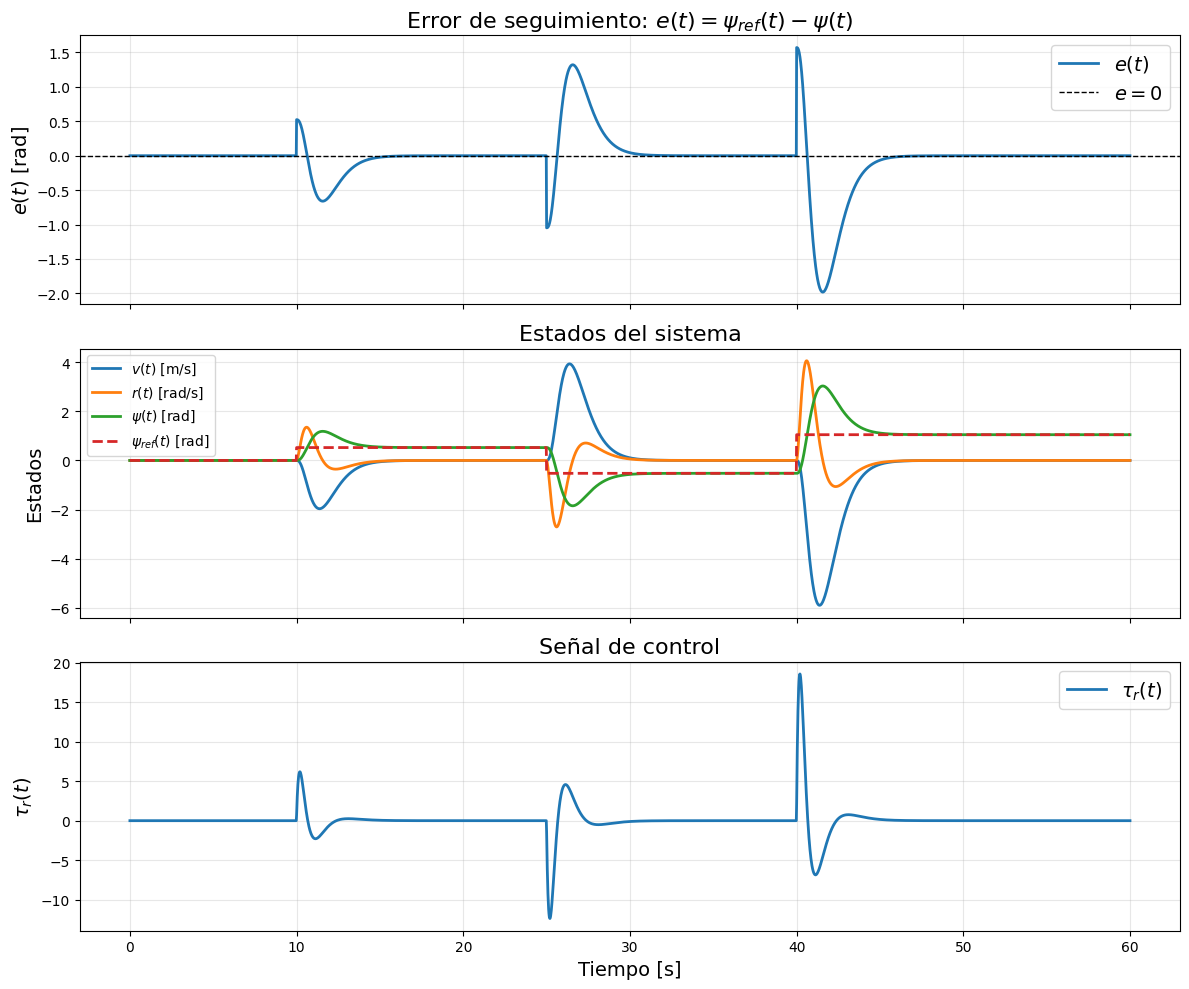

In [9]:
fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

ax1, ax2, ax3 = axs
label_fontsize = 14
legend_fontsize = 14
title_fontsize = 16

# Error de seguimiento
ax1.plot(T_sim, e, linewidth=2, label=r'$e(t)$')
ax1.axhline(0, color='black', linestyle='--', linewidth=1, label=r'$e=0$')
ax1.set_ylabel(r'$e(t)$ [rad]', fontsize=label_fontsize)
ax1.set_title(r'Error de seguimiento: $e(t)=\psi_{ref}(t)-\psi(t)$', fontsize=title_fontsize)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=legend_fontsize)

# Estados del sistema
ax2.plot(T_sim, v, label=r'$v(t)$ [m/s]', linewidth=2)
ax2.plot(T_sim, r, label=r'$r(t)$ [rad/s]', linewidth=2)
ax2.plot(T_sim, psi, label=r'$\psi(t)$ [rad]', linewidth=2)
ax2.plot(T_sim, psi_ref, '--', label=r'$\psi_{ref}(t)$ [rad]', linewidth=2)
ax2.set_ylabel('Estados', fontsize=label_fontsize)
ax2.set_title('Estados del sistema', fontsize=title_fontsize)
ax2.legend(fontsize=legend_fontsize)
ax2.grid(True, alpha=0.3)
ax2.legend()

# Señal de control
ax3.plot(T_sim, tau_r, linewidth=2, label=r'$\tau_r(t)$')
ax3.set_xlabel('Tiempo [s]', fontsize=label_fontsize)
ax3.set_ylabel(r'$\tau_r(t)$', fontsize=label_fontsize)
ax3.set_title('Señal de control', fontsize=title_fontsize)
ax3.grid(True, alpha=0.3)
ax3.legend(fontsize=legend_fontsize)

plt.tight_layout()
plt.show()

In [10]:
print("Máximo error absoluto:", np.max(np.abs(e)))
print("Máximo tau_r absoluto:", np.max(np.abs(tau_r)))
print("Máximo v absoluto:", np.max(np.abs(v)))
print("Máximo r absoluto:", np.max(np.abs(r)))

Máximo error absoluto: 1.9810266825708152
Máximo tau_r absoluto: 18.598933919521073
Máximo v absoluto: 5.8902792261588415
Máximo r absoluto: 4.05368814218319


### 8)  FALTA

* Si la embarcaci´on logra seguir la referencia de rumbo.
* Si el error estacionario es nulo.
* Si la velocidad de respuesta del sistema es adecuada para el problema.
* Si la suavidad de la se˜nal de control.
* Si los valores m´aximos requeridos de τr.
* C´omo cambia la respuesta al modificar la ubicaci´on de los polos (para esto, puede graficar ambos resultados).
* Las posibles limitaciones f´ısicas del actuador.

### Guardado de resultados en un .json para posteriores notebooks

In [11]:
metrics_A = {
    "max_abs_error": float(np.max(np.abs(e))),
    "max_abs_tau": float(np.max(np.abs(tau_r))),
    "max_abs_v": float(np.max(np.abs(v))),
    "max_abs_r": float(np.max(np.abs(r))),
    "max_abs_psi": float(np.max(np.abs(psi))),
    "final_error": float(e[-1]),
    "rms_tau": float(np.sqrt(np.mean(tau_r**2))),
    "iae": float(np.trapezoid(np.abs(e), T_sim)),
    "ise": float(np.trapezoid(e**2, T_sim))
}

data = {
    "A": A.tolist(),
    "B": B.tolist(),
    "C": C.tolist(),

    "A_a": A_a.tolist(),
    "B_a": B_a.tolist(),
    "E_a": E_a.tolist(),

    "Ka": Ka.tolist(),
    "poles": [[complex(p).real, complex(p).imag] for p in poles],

    "T": T_sim.tolist(),
    "psi_ref": psi_ref.tolist(),

    "x_a": yout.tolist(),
    "v": v.tolist(),
    "r": r.tolist(),
    "psi": psi.tolist(),
    "xi": xi.tolist(),

    "error": e.tolist(),
    "tau_r": tau_r.tolist(),

    "metrics": metrics_A
}
path = "resultados/parteA.json"
if not os.path.exists("resultados"):
    os.makedirs("resultados")

with open(path, "w") as f:
    json.dump(data, f)

NameError: name 'yout' is not defined